# Machine Translation

Uncomment this if you are using Colab. Please reserve at least 80GB storage.

In [28]:
# from google.colab import drive
# drive.mount('/content/drive')

In [29]:
# cd /content/drive/MyDrive/Machine Learning/Project

In [45]:
!pip install transformers datasets sacrebleu sentencepiece accelerate evaluate seaborn pandas matplotlib dotenv jsonlines sacremoses

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 10.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [31]:
import os, json, math, time
import dotenv
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    AutoModelForSeq2SeqLM,
)
import torch
import numpy as np
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import jsonlines

dotenv.load_dotenv('.env')

True

## Load Dataset WMT17

Device space limitation.

In [32]:
SUPPORTED_LANGS = ['zh-en'] #'cs-en', 'de-en', 'fi-en', 'lv-en', 'ru-en', 'tr-en', ]
lang_map = {
        'en': 'en_XX',
        'zh': 'zh_CN',
        'cs': 'cs_CZ',
        'de': 'de_DE',
        'fi': 'fi_FI',
        'lv': 'lv_LV',
        'ru': 'ru_RU',
        'tr': 'tr_TR',
    }

## Load Pretrained Model.

https://huggingface.co/Helsinki-NLP/opus-mt-zh-en

In [33]:
def build_model(src_lang, tgt_lang):
    # model_name = "facebook/mbart-large-50-many-to-many-mmt"
    model_name = 'Helsinki-NLP/opus-mt-zh-en'
    tok = AutoTokenizer.from_pretrained(model_name, src_lang=src_lang, tgt_lang=tgt_lang, cache_dir='./cache')
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name, cache_dir='./cache')
    return tok, model


## Load MT Metrics

In [34]:
from evaluate import load

bleu = load("sacrebleu", cache_dir='./cache')
chrf = load("chrf", cache_dir='./cache')

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    labels = np.where(labels != -100, labels, tok.pad_token_id)
    pred_str = tok.batch_decode(preds, skip_special_tokens=True)
    label_str = tok.batch_decode(labels, skip_special_tokens=True)
    bleu_score  = bleu.compute(predictions=pred_str,
                                 references=[[r] for r in label_str])["score"]
    chrf_score  = chrf.compute(predictions=pred_str,
                                 references=label_str)["score"]

    return {"bleu": bleu_score, "chrf": chrf_score}

## Preprocess Datasets

In [35]:
def split_train_test(full_train, num_trains, num_test, num_val, seed=42):
    random.seed(seed)

    raw_train = full_train.select(random.sample(range(len(full_train)), num_trains))
    raw_test = full_train.select(random.sample(range(len(full_train)), num_test))
    raw_val = full_train.select(random.sample(range(len(full_train)), num_val))
    return raw_train, raw_test, raw_val


In [36]:
def flip_dataset(raw, src, tgt):
    def flip(batch):
        batch["translation"] = {src: batch["translation"][tgt],
                                tgt: batch["translation"][src]}
        return batch
    return raw.map(flip, batched=False)


In [37]:
def clean_memory():
    import torch, gc
    if torch.cuda.is_available():
        torch.cuda.empty_cache()  # 把未用缓存还给 CUDA
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()   # 把未用缓存还给 CUDA
    gc.collect()               # 再让 Python 回收一次

In [38]:
def train_evaluate(src, tgt, num_train=10, num_test=10, num_val=10, reverse=False):
    global tok, model
# ['cs-en', 'de-en', 'fi-en', 'lv-en', 'ru-en', 'tr-en', 'zh-en']
    model_name = 'mbert'
    data = load_dataset("wmt17", name="-".join([src, tgt]), split="test", cache_dir='./cache')
    if reverse:
        data = flip_dataset(data, src, tgt)
        src, tgt = tgt, src

    lang_src = lang_map[src]
    lang_tgt = lang_map[tgt]
    tok, model = build_model(lang_src, lang_tgt)

    prefix = f'{model_name}-{src}-{tgt}'
    num_train_epochs = 10
    max_src, max_tgt = 128, 128

    def encode(ex):
        en_sent = [item[src] for item in ex["translation"]]
        zh_sent = [item[tgt] for item in ex["translation"]]
        # 一次调用同时编码源端和目标端
        model_inputs = tok(
            en_sent,
            text_target=zh_sent,
            max_length=max_src,
            truncation=True,
            padding=False,          # 动态 padding，由 data_collator 完成
        )
        return model_inputs

    raw_train, raw_test, raw_val = split_train_test(data,
                                                    num_trains=num_train, num_test=num_test, num_val=num_val)

    tokenised_train = raw_train.map(encode, batched=True)
    tokenised_val = raw_val.map(encode, batched=True)
    tokenised_test = raw_test.map(encode, batched=True)

    data_coll = DataCollatorForSeq2Seq(tok, model=model)

    args = Seq2SeqTrainingArguments(
        # output_dir='/content/output',
        eval_strategy="steps",
        eval_steps=500,
        logging_steps=100,
        save_steps=500,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=3e-5,
        num_train_epochs=num_train_epochs,
        predict_with_generate=True,
        generation_max_length=max_tgt,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="bleu",
        greater_is_better=True,
        report_to="none",
        fp16=True,
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=tokenised_train,
        eval_dataset=tokenised_val,
        processing_class=tok,
        data_collator=data_coll,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()

    eval_result = trainer.evaluate(tokenised_test)
    eval_result.update(src=src, tgt=tgt, num_train=num_train, num_test=num_test, num_val=num_val, reverse=reverse, model_name=model_name)

    writer = jsonlines.open('wmt17_results.jsonl', mode='a')
    writer.write(eval_result)
    writer.close()
    return eval_result



## Run Experiments

In [43]:
def parameter_grid():
    for rep in range(3):
        for lang_pair in SUPPORTED_LANGS:
            src, tgt = lang_pair.split('-')
            for num_train in [8, 16, 32, 64, 128, 256, 512, 1024, 4096]:
                for num_test in [20]:
                    num_val = int(0.1 * num_train)
                    yield dict(src=src, tgt=tgt,
                                num_train=num_train, num_test=num_test, num_val=num_val, reverse=False)

params_list = list(parameter_grid())
random.shuffle(params_list)


In [ ]:
for params in params_list:
    clean_memory()
    print(params)
    try:
        train_evaluate(**params)
        print('OK')
    except Exception as e:
        print(f'Error processing {e}')


{'src': 'zh', 'tgt': 'en', 'num_train': 1024, 'num_test': 20, 'num_val': 102, 'reverse': False}


Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

Map:   0%|          | 0/102 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


...

Step,Training Loss,Validation Loss


/Users/fengcong/miniconda3/envs/py312/lib/python3.12/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[65000]]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
/Users/fengcong/miniconda3/envs/py312/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


OK
{'src': 'zh', 'tgt': 'en', 'num_train': 1024, 'num_test': 20, 'num_val': 102, 'reverse': False}


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss,Validation Loss


## Results

In [41]:
df = pd.read_json('wmt17_results.jsonl', lines=True)
df = pd.melt(df, id_vars=['src', 'tgt', 'num_train', 'num_test', 'num_val', 'reverse', 'model_name'], 
             value_vars=['eval_bleu', 'eval_chrf'],
             var_name='metric',
             value_name='value')

<Axes: xlabel='num_train', ylabel='value'>

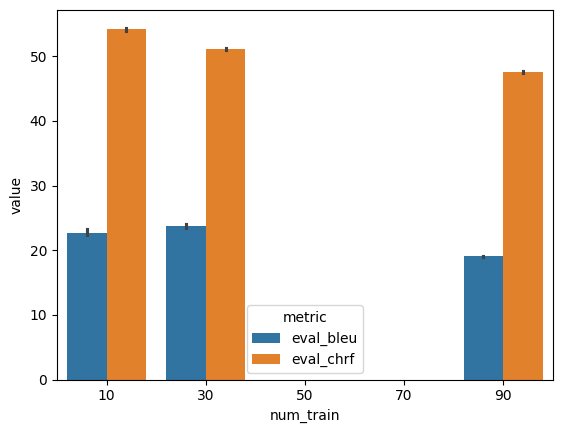

In [42]:
sns.barplot(data=df, x='num_train', y='value', hue='metric')